In [24]:
import pandas as pd
from setuptools.command import install

In [25]:
df=pd.read_csv("C:/Users/chaur/Downloads/Big_Black_Money_Dataset.csv")

In [26]:
df.head()


,h,Country,Amount (USD),Transaction Type,Date of Transaction,Person Involved,Industry,Destination Country,Reported by Authority,Source of Money,Money Laundering Risk Score,Shell Companies Involved,Financial Institution,Tax Haven Country
0,TX0000000001,Brazil,3.267530e+06,Offshore Transfer,01-01-2013 00:00,Person_1101,Construction,USA,True,Illegal,6,1,Bank_40,Singapore
1,TX0000000002,China,4.965767e+06,Stocks Transfer,01-01-2013 01:00,Person_7484,Luxury Goods,South Africa,False,Illegal,9,0,Bank_461,Bahamas
2,TX0000000003,UK,9.416750e+04,Stocks Transfer,01-01-2013 02:00,Person_3655,Construction,Switzerland,True,Illegal,1,3,Bank_387,Switzerland
3,TX0000000004,UAE,3.864201e+05,Cash Withdrawal,01-01-2013 03:00,Person_3226,Oil & Gas,Russia,False,Illegal,7,2,Bank_353,Panama
4,TX0000000005,South Africa,6.433784e+05,Cryptocurrency,01-01-2013 04:00,Person_7975,Real Estate,USA,True,Illegal,1,9,Bank_57,Luxembourg


In [27]:
df.tail()

,h,Country,Amount (USD),Transaction Type,Date of Transaction,Person Involved,Industry,Destination Country,Reported by Authority,Source of Money,Money Laundering Risk Score,Shell Companies Involved,Financial Institution,Tax Haven Country
9995,TX0000009996,Singapore,2.209229e+06,Offshore Transfer,21-02-2014 11:00,Person_6896,Real Estate,Brazil,False,Illegal,4,4,Bank_258,Luxembourg
9996,TX0000009997,UAE,4.800338e+06,Property Purchase,21-02-2014 12:00,Person_6348,Luxury Goods,Russia,False,Legal,10,2,Bank_449,Luxembourg
9997,TX0000009998,UK,4.891953e+05,Stocks Transfer,21-02-2014 13:00,Person_4171,Oil & Gas,Russia,False,Illegal,5,0,Bank_156,Cayman Islands
9998,TX0000009999,Brazil,2.233581e+06,Offshore Transfer,21-02-2014 14:00,Person_2799,Real Estate,Russia,True,Illegal,10,5,Bank_12,Singapore
9999,TX0000010000,Switzerland,3.846778e+05,Stocks Transfer,21-02-2014 15:00,Person_3267,Arms Trade,China,True,Legal,5,4,Bank_22,Panama


In [28]:
df.isnull().sum()

h                              0
Country                        0
Amount (USD)                   0
Transaction Type               0
Date of Transaction            0
Person Involved                0
Industry                       0
Destination Country            0
Reported by Authority          0
Source of Money                0
Money Laundering Risk Score    0
Shell Companies Involved       0
Financial Institution          0
Tax Haven Country              0
dtype: int64

In [29]:
df.info()



<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   h                            10000 non-null  str    
 1   Country                      10000 non-null  str    
 2   Amount (USD)                 10000 non-null  float64
 3   Transaction Type             10000 non-null  str    
 4   Date of Transaction          10000 non-null  str    
 5   Person Involved              10000 non-null  str    
 6   Industry                     10000 non-null  str    
 7   Destination Country          10000 non-null  str    
 8   Reported by Authority        10000 non-null  bool   
 9   Source of Money              10000 non-null  str    
 10  Money Laundering Risk Score  10000 non-null  int64  
 11  Shell Companies Involved     10000 non-null  int64  
 12  Financial Institution        10000 non-null  str    
 13  Tax Haven Country           

In [30]:

df["Date of Transaction"]=pd.to_datetime(df["Date of Transaction"],dayfirst=True,errors='coerce')

In [31]:
df["Year"]=df["Date of Transaction"].dt.year
df["Month"]=df["Date of Transaction"].dt.month

In [32]:
df.groupby("Country")["Money Laundering Risk Score"].mean()

Country
Brazil          5.579523
China           5.510597
India           5.613131
Russia          5.428285
Singapore       5.585930
South Africa    5.476608
Switzerland     5.557360
UAE             5.478484
UK              5.542406
USA             5.492292
Name: Money Laundering Risk Score, dtype: float64

In [33]:
df.groupby("Shell Companies Involved")["Money Laundering Risk Score"].mean()

Shell Companies Involved
0    5.619545
1    5.698990
2    5.555000
3    5.482125
4    5.359799
5    5.586006
6    5.470352
7    5.587576
8    5.572008
9    5.325253
Name: Money Laundering Risk Score, dtype: float64

In [35]:
df.groupby("Country")["Money Laundering Risk Score"].mean().sort_values(ascending=False)

Country
India           5.613131
Singapore       5.585930
Brazil          5.579523
Switzerland     5.557360
UK              5.542406
China           5.510597
USA             5.492292
UAE             5.478484
South Africa    5.476608
Russia          5.428285
Name: Money Laundering Risk Score, dtype: float64

In [53]:
import matplotlib.pyplot as plt

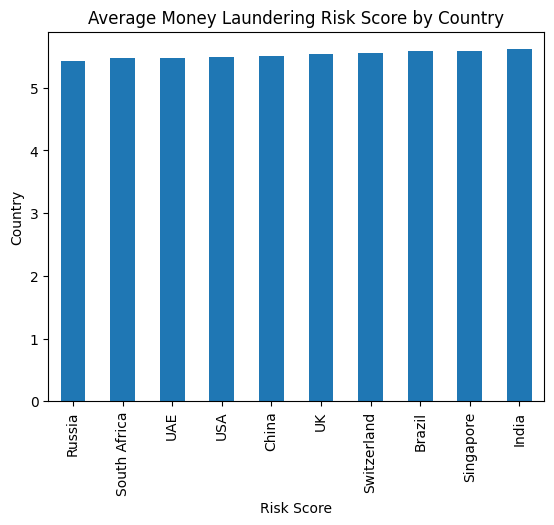

In [54]:
df.groupby("Country")["Money Laundering Risk Score"].mean().sort_values().plot(kind="bar")
plt.title("Average Money Laundering Risk Score by Country")
plt.xlabel("Risk Score")
plt.ylabel("Country")
plt.show()

In [55]:
df.groupby("Transaction Type")["Money Laundering Risk Score"].mean().sort_values(ascending=False)

Transaction Type
Stocks Transfer      5.596571
Cash Withdrawal      5.550556
Property Purchase    5.507670
Cryptocurrency       5.506842
Offshore Transfer    5.471212
Name: Money Laundering Risk Score, dtype: float64

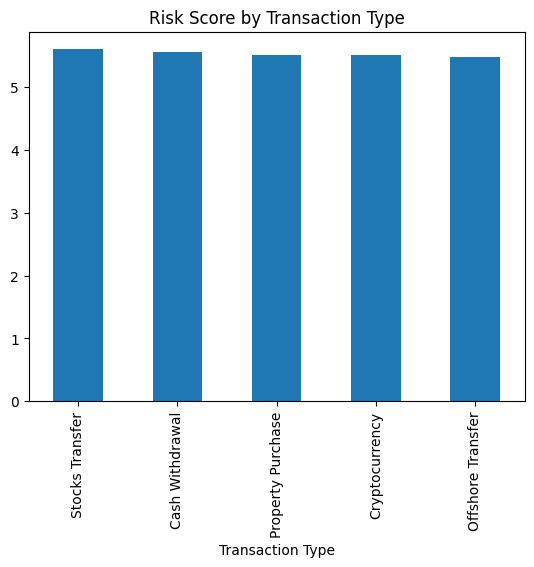

In [56]:
df.groupby("Transaction Type")["Money Laundering Risk Score"].mean().sort_values(ascending=0).plot(kind="bar")
plt.title("Risk Score by Transaction Type")
plt.show()

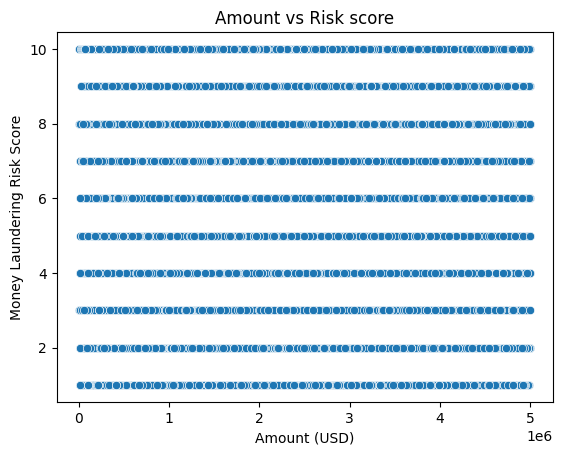

In [59]:
import  seaborn as se
se.scatterplot(x="Amount (USD)", y="Money Laundering Risk Score",data=df)
plt.title("Amount vs Risk score")
plt.show()

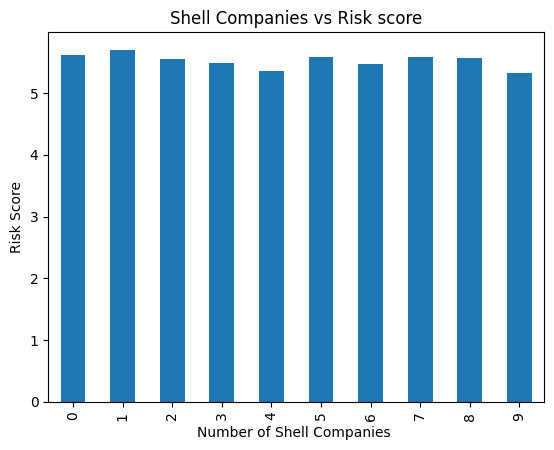

In [61]:
df.groupby("Shell Companies Involved")["Money Laundering Risk Score"].mean().plot(kind="bar")
plt.title("Shell Companies vs Risk score")
plt.xlabel("Number of Shell Companies ")
plt.ylabel("Risk Score")
plt.show()

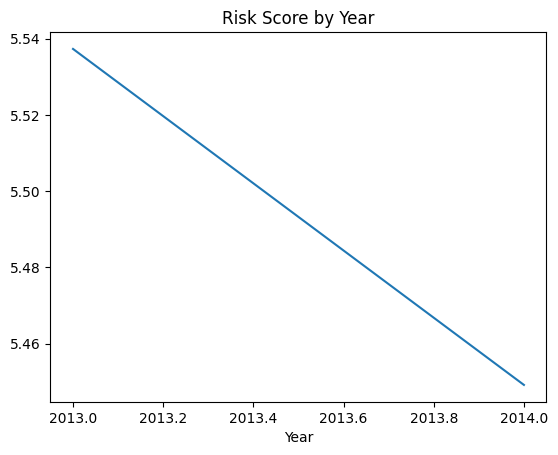

In [62]:
df.groupby("Year")["Money Laundering Risk Score"].mean().plot()
plt.title("Risk Score by Year")
plt.show()